<a href="https://colab.research.google.com/github/actelleza-maker/Ciencia-de-datos-con-IA/blob/main/Copia_de_Hands_On_Introducci%C3%B3n_a_la_Estad%C3%ADstica_Inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**


Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Importar dataset
df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [ ]:
# Importar módulo
from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

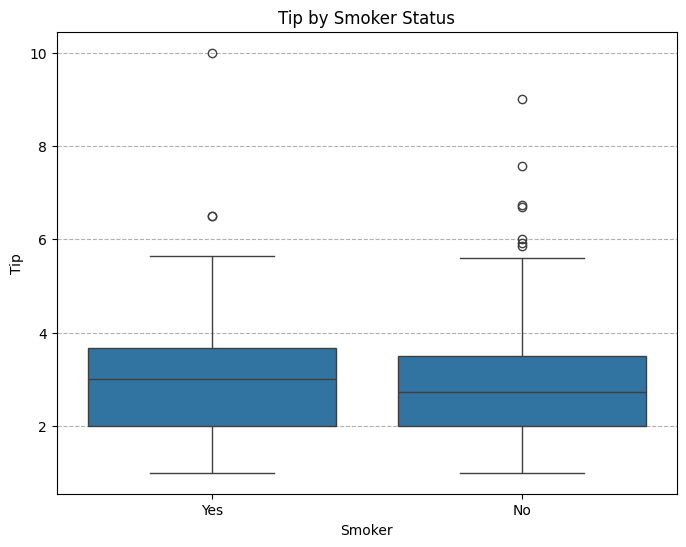

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='tip', data=df_tips)
plt.title('Tip by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Tip')
plt.grid(axis='y', linestyle='--')
plt.show()

In [ ]:
# Separaración de grupos
propinas_fumadores = df_tips[df_tips['smoker'] == 'Yes']['tip']
propinas_no_fumadores = df_tips[df_tips['smoker'] == 'No']['tip']

In [ ]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(propinas_fumadores, propinas_no_fumadores)

print("Estadístico t:", t_stat)
print("Valor p:", p_value)

Estadístico t: 0.09222805186888201
Valor p: 0.9265931522244976


In [ ]:

# Interpretar resultados
def interpretar_pvalue(p_value):
    if p_value < 0.01:
      print("\nConclusión: Rechazamos la Hipótesis Nula.")
      print("Existe una diferencia muy significativa entre tus muestras")
    if p_value>=0.01 and p_value < 0.05:
      print("\nConclusión: Rechazamos la Hipótesis Nula.")
      print("Existe una diferencia altamente significativa entre tus muestras")
    if p_value>=0.05 and p_value < 0.10:
      print("\nConclusión: Rechazamos la Hipótesis Nula.")
      print("Existe una diferencia moderadamente significativa entre tus muestras")
    else:
      print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
      print("No hay evidecnia suficiente para concluir que las medias son diferentes")



In [ ]:
interpretar_pvalue(p_value)


Conclusión: No podemos rechazar la Hipótesis Nula.
No hay evidecnia suficiente para concluir que las medias son diferentes


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

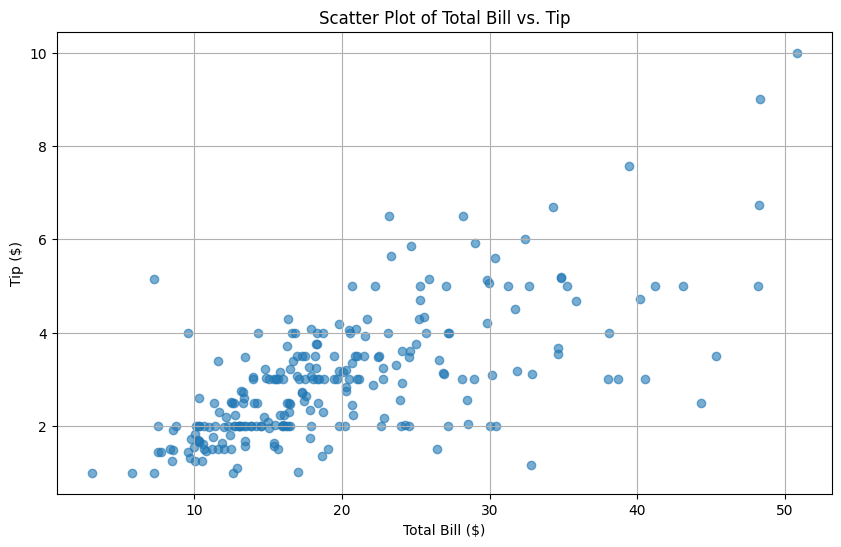

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6)
plt.title('Scatter Plot of Total Bill vs. Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True)
plt.show()

In [ ]:
x = df_tips['total_bill']
y = df_tips['tip']

In [ ]:
# Definir regresión lineal
linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')


y = 0.10502451738435338 x + 0.920269613554673


In [ ]:
# Predicción de valores con regresión lineal
tb_pred_lr = int(input('Agrega el valor del total de la cuenta que quieras predecir la propina:'))
y_pred_lr = round(beta * tb_pred_lr + alpha, 2)

print(f'Lapropina será de {y_pred_lr}')

Agrega el valor del total de la cuenta que quieras predecir la propina:20
Lapropina será de 3.02


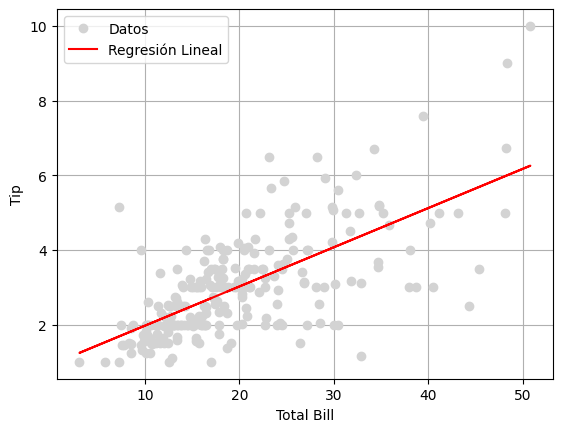

In [ ]:
# Visualizar regresión lineal
plt.plot(x,y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta * x + alpha, 'r', label = 'Regresión Lineal')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [ ]:

y_pred_err = np.polyval(linear_regression, x)
error = ((y-y_pred_err) **2).mean()

print(f'El error cuadrático medio es: {error}')



El error cuadrático medio es: 1.036019442011377


#### Ejemplo Split

In [ ]:
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


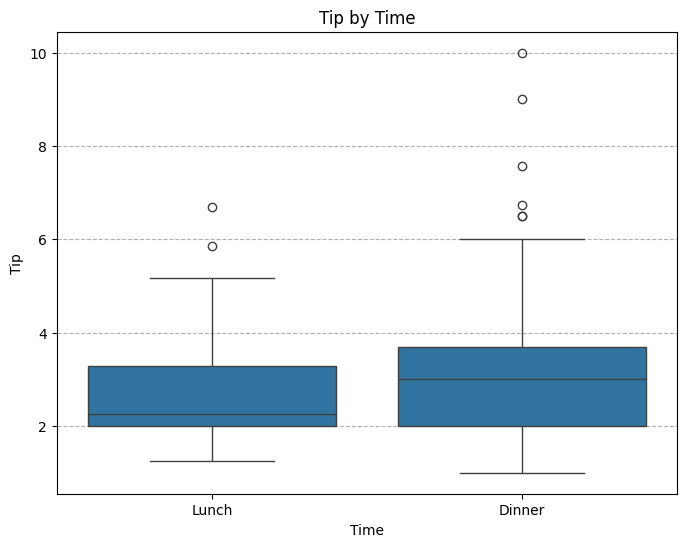

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='time', y='tip', data=df_tips)
plt.title('Tip by Time')
plt.xlabel('Time')
plt.ylabel('Tip')
plt.grid(axis='y', linestyle='--')
plt.show()

In [ ]:
x_lunch = df_tips[df_tips['time'] == 'Lunch']['total_bill']
y_lunch = df_tips[df_tips['time'] == 'Lunch']['tip']

x_dinner = df_tips[df_tips['time'] == 'Dinner']['total_bill']
y_dinner = df_tips[df_tips['time'] == 'Dinner']['tip']

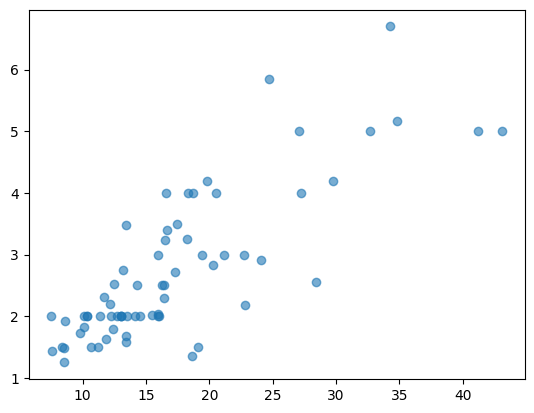

In [ ]:
plt.scatter(x_lunch, y_lunch, alpha=0.6, label='Lunch')
plt.show()

In [ ]:
linear_regression_lunch = np.polyfit(x_lunch, y_lunch, 1)
beta_l, alpha_l = linear_regression_lunch

print(f'y = {beta_l} x + {alpha_l}')

y = 0.12585283540007594 x + 0.5673616214040186


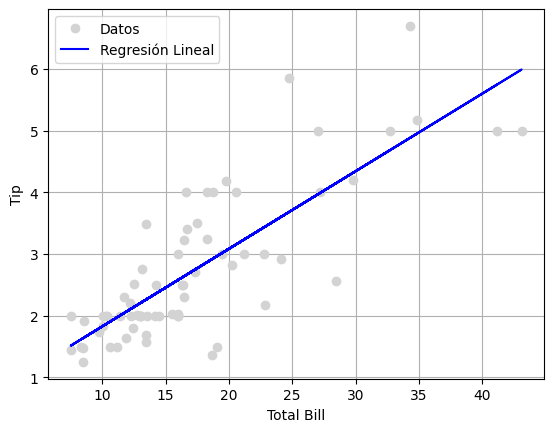

In [ ]:
# Visualizar regresión lineal
plt.plot(x_lunch,y_lunch, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x_lunch, beta_l * x_lunch + alpha_l, 'blue', label = 'Regresión Lineal')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [ ]:
y_pred_err_l = np.polyval(linear_regression_lunch, x_lunch)
error = ((y_lunch-y_pred_err_l) **2).mean()
print(f'El error cuadrático medio es: {error}')
rmse = np.sqrt(error)
print(f'El error cuadrático medio es: {rmse}')

El error cuadrático medio es: 0.5028722996181249
El error cuadrático medio es: 0.7091348952196083


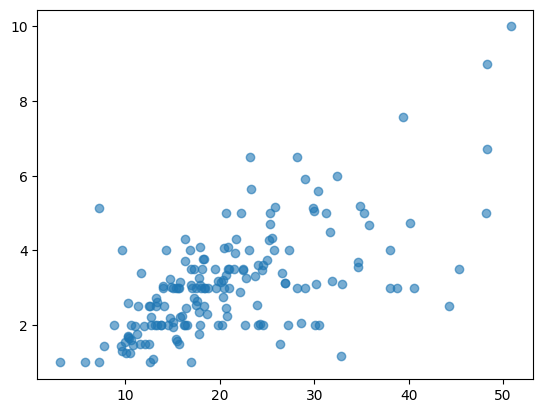

In [ ]:
plt.scatter(x_dinner, y_dinner, alpha=0.6, label='Dinner')
plt.show()

In [ ]:
linear_regression_dinner = np.polyfit(x_dinner, y_dinner, 1)
beta_d, alpha_d = linear_regression_dinner

print(f'y = {beta_d} x + {alpha_d}')

y = 0.09942615154524889 x + 1.0348889630620777


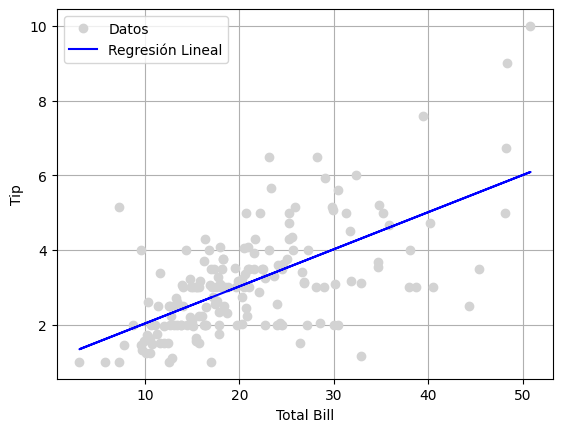

In [ ]:
plt.plot(x_dinner,y_dinner, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x_dinner, beta_d * x_dinner + alpha_d, 'blue', label = 'Regresión Lineal')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [ ]:
y_pred_err_d = np.polyval(linear_regression_dinner, x_dinner)
error = ((y_dinner-y_pred_err_d) **2).mean()
print(f'El error cuadrático medio es: {error}')
rmse = np.sqrt(error)
print(f'El error cuadrático medio es: {rmse}')

El error cuadrático medio es: 1.2295648936948123
El error cuadrático medio es: 1.108857472218505


#### Función de pérdida

In [ ]:
# Iterar pérdida de la regresión lineal
num_iteraciones = 100
perdida =[]

for i in range(num_iteraciones):
  y_pred = np.polyval(linear_regression, x)
  error = ((y-y_pred) **2).mean()
  perdida.append(error)

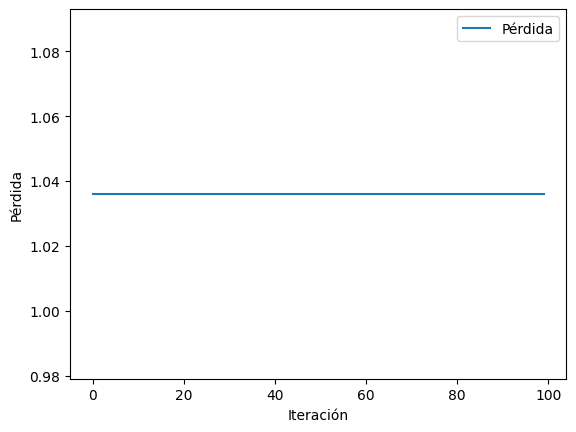

In [ ]:
# Visualizar pérdida de la regresión lineal
plt.plot(perdida, label='Pérdida')
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.legend()

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [ ]:
# Definir parámetros
tamaño_paso = 0.001 #Alpha
theta_0 = 0.1
theta_1 = 0.1

perdida = []


La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [ ]:
n = len(df_tips['total_bill'])
print(n)

244


In [ ]:
# Realizar algoritmo del descenso de gradiente
# y = 0.10502451738435338 x + 0.920269613554673

num_iteraciones = 100

for i in range(num_iteraciones):
  y_pred = theta_1 * x + theta_0
  error = ((y_pred - y)**2).mean()
  perdida.append(error)

  d_theta_0 = (2 /n) * np.sum(y_pred - y)
  d_theta_1 = (2 /n) * np.sum((y_pred - y) * x)

  theta_0 = theta_0 - (tamaño_paso * d_theta_0)
  theta_1 = theta_1 - (tamaño_paso * d_theta_1)

print(f'y = {theta_1} x + {theta_0}')

y = 0.13833335564554403 x + 0.1286324781176542


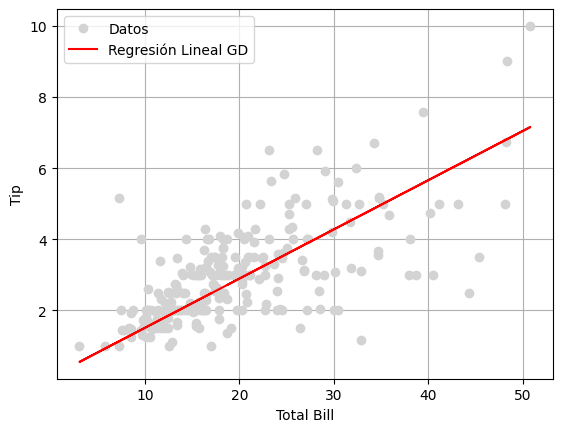

In [ ]:
# Visualizar la regresión lineal por descenso de gradiente
plt.plot(x,y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Regresión Lineal GD')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Predicción de valores con descenso de gradiente
tb_pred_gd = int(input('Agrega el valor del total de la cuenta que quieras predecir la propina:'))
y_pred_gd = round(theta_1 * tb_pred_gd + theta_0, 2)

print(f'Lapropina será de {y_pred_gd}')

Agrega el valor del total de la cuenta que quieras predecir la propina:20
Lapropina será de 2.9


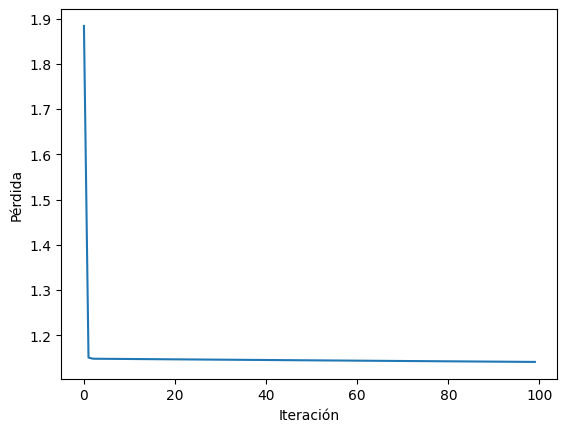

In [ ]:
# Visualizar las pérdidas
plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

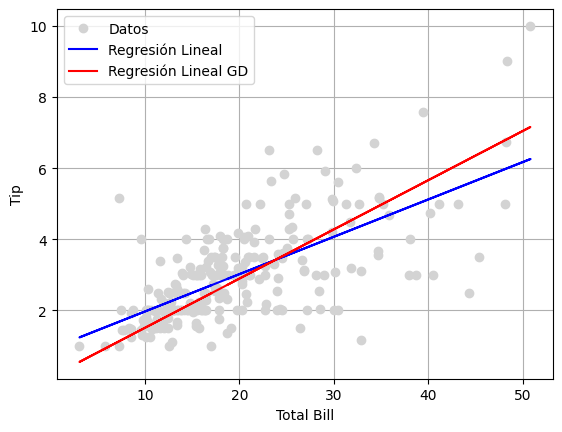

In [ ]:
# Comparar las rectas obtenidas por los algoritmos
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta * x + alpha, color = 'blue', label = 'Regresión Lineal')
plt.plot(x, theta_1 * x + theta_0, color= 'red', label = 'Regresión Lineal GD')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [ ]:
perdida[9998]

np.float64(1.0361579333785682)